# Fase 0: Configuración del Entorno

**Proyecto:** Sistema de Predicción MLT  
**Referencia:** `PLAN_PASO_A_PASO.md` → Fase 0  
**Objetivo:** Verificar que todas las librerías están instaladas, detectar GPU y configurar el entorno de trabajo.

---

## Fundamento Matemático

Este notebook no implementa modelos, pero configura el entorno para los cálculos que seguirán. La notación LaTeX que usaremos a lo largo del proyecto:

$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i \qquad \text{(Media aritmética)}$$

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu)^2 \qquad \text{(Varianza muestral)}$$

$$P_{\text{baseline}}(k) = \frac{m}{N} = \frac{6}{56} \approx 0.1071 \qquad \text{(Probabilidad uniforme por número)}$$

$$\mathbb{E}[\text{aciertos}] = \frac{m^2}{N} = \frac{36}{56} \approx 0.643 \qquad \text{(Aciertos esperados por azar)}$$

## 0.1 — Semilla de Reproducibilidad

Fijamos `RANDOM_STATE` como constante global. Toda operación estocástica del proyecto debe usar esta semilla.

$$\text{Reproducibilidad:} \quad f(\text{datos}, \text{seed}) \rightarrow \text{resultado determinista}$$

In [ ]:
RANDOM_STATE = 42
PROJECT_NAME = "MLT Prediccion"
PROJECT_VERSION = "2.0"

print(f"Proyecto: {PROJECT_NAME} v{PROJECT_VERSION}")
print(f"Semilla global: {RANDOM_STATE}")

## 0.2 — Importación de Librerías Core

Stack principal definido en `PLAN_MATEMATICO_MLT.md`:

| Librería | Uso |
|----------|-----|
| `numpy` | Operaciones vectorizadas: $\vec{x} \cdot \vec{y} = \sum x_i y_i$ |
| `pandas` | DataFrames para datos tabulares |
| `scipy` | Tests estadísticos: $\chi^2$, Kolmogorov-Smirnov, distribución $\text{Beta}(\alpha, \beta)$ |
| `scikit-learn` | Modelos ML, pipelines, validación, calibración |
| `matplotlib` | Visualización base |
| `seaborn` | Visualización estadística |

In [30]:
import sys
import os
import hashlib
import platform
import warnings
from datetime import datetime

print(f"Python: {sys.version}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Timestamp: {datetime.now().isoformat()}")
print("---")

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
OS: Windows 11
Timestamp: 2026-03-29T14:43:30.982750
---


In [31]:
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

np.random.seed(RANDOM_STATE)

print("Librerias core importadas correctamente")

Librerias core importadas correctamente


## 0.3 — Importación de Librerías ML Específicas

Modelos y herramientas de scikit-learn que usaremos:

- **RandomForestClassifier**: Ensamble de $B$ árboles con bootstrap
$$P(y_k=1|\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

- **GradientBoostingClassifier**: Boosting secuencial
$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

- **CalibratedClassifierCV**: Calibración Platt/Isotónica
$$P_{\text{cal}} = \frac{1}{1 + \exp(A \cdot P_{\text{raw}} + B)}$$

In [32]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.pipeline import Pipeline

from scipy import stats
from scipy.special import comb

print("Modulos sklearn/scipy importados correctamente")

Modulos sklearn/scipy importados correctamente


## 0.4 — XGBoost (Gradient Boosting con soporte GPU)

XGBoost optimiza la función objetivo regularizada:

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{j=1}^{T} \left[ \gamma T_j + \frac{\lambda}{2} \|w_j\|^2 \right]$$

Donde $\gamma$ penaliza la complejidad (hojas) y $\lambda$ regulariza los pesos.

In [33]:
xgb_available = False
try:
    import xgboost as xgb
    xgb_available = True
    print(f"XGBoost: {xgb.__version__} — OK")
except ImportError:
    print("XGBoost: NO INSTALADO")
    print("  -> Instalar con: pip install xgboost")
    print("  -> Se usara sklearn.GradientBoostingClassifier como fallback")

XGBoost: 3.2.0 — OK


## 0.5 — Optuna (Hyperparameter Tuning Bayesiano)

Optuna usa optimización bayesiana con Tree-structured Parzen Estimator (TPE) para buscar hiperparámetros de forma eficiente, respetando el orden temporal con `TimeSeriesSplit`.

In [35]:
optuna_available = False
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    optuna_available = True
    print(f"Optuna: {optuna.__version__} — OK")
except ImportError:
    print("Optuna: NO INSTALADO")
    print("  -> Instalar con: pip install optuna")
    print("  -> Se usara busqueda manual como fallback")

Optuna: 4.8.0 — OK


C:\Users\rasta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.6 — Detección de GPU

Verificamos disponibilidad de aceleración por GPU para XGBoost y operaciones numéricas.

XGBoost con GPU usa el parámetro `device='cuda'` para entrenar en GPU NVIDIA con CUDA.

In [36]:
gpu_info = {
    'cuda_available': False,
    'gpu_name': 'N/A',
    'gpu_memory': 'N/A',
    'xgb_gpu': False,
    'device': 'cpu'
}

# --- Deteccion via PyTorch (si esta instalado) ---
try:
    import torch
    if torch.cuda.is_available():
        gpu_info['cuda_available'] = True
        gpu_info['gpu_name'] = torch.cuda.get_device_name(0)
        mem_gb = torch.cuda.get_device_properties(0).total_mem / (1024**3)
        gpu_info['gpu_memory'] = f"{mem_gb:.1f} GB"
        gpu_info['device'] = 'cuda'
        print(f"PyTorch CUDA: DISPONIBLE")
        print(f"  GPU: {gpu_info['gpu_name']}")
        print(f"  Memoria: {gpu_info['gpu_memory']}")
    else:
        print("PyTorch CUDA: No disponible")
except ImportError:
    print("PyTorch: No instalado (no requerido, solo para deteccion de GPU)")

# --- Deteccion directa via XGBoost ---
if xgb_available:
    try:
        test_dmatrix = xgb.DMatrix(np.array([[1, 2], [3, 4]]), label=[0, 1])
        test_params = {'device': 'cuda', 'verbosity': 0}
        xgb.train(test_params, test_dmatrix, num_boost_round=1)
        gpu_info['xgb_gpu'] = True
        gpu_info['device'] = 'cuda'
        print(f"XGBoost GPU (CUDA): DISPONIBLE")
    except Exception as e:
        print(f"XGBoost GPU: No disponible ({type(e).__name__})")
        print("  -> XGBoost usara CPU")

# --- Deteccion via nvidia-smi (fallback) ---
if not gpu_info['cuda_available'] and not gpu_info['xgb_gpu']:
    try:
        import subprocess
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        if result.returncode == 0 and result.stdout.strip():
            gpu_line = result.stdout.strip().split('\n')[0]
            print(f"nvidia-smi detecta GPU: {gpu_line}")
            print("  -> GPU presente pero drivers CUDA/XGBoost no configurados")
            gpu_info['gpu_name'] = gpu_line
        else:
            print("nvidia-smi: No se detecta GPU NVIDIA")
    except (FileNotFoundError, subprocess.TimeoutExpired):
        print("nvidia-smi: No disponible")

print("\n" + "="*50)
print(f"DISPOSITIVO SELECCIONADO: {gpu_info['device'].upper()}")
print("="*50)

PyTorch: No instalado (no requerido, solo para deteccion de GPU)
XGBoost GPU (CUDA): DISPONIBLE

DISPOSITIVO SELECCIONADO: CUDA


## 0.7 — Verificación de Versiones

Comparamos las versiones instaladas contra las esperadas en `requirements.txt`.

In [37]:
expected_versions = {
    'numpy': '2.4.3',
    'pandas': '3.0.1',
    'scipy': '1.17.1',
    'scikit-learn': '1.8.0',
    'matplotlib': '3.10.8',
    'seaborn': '0.13.2',
    'requests': '2.33.0',
    'joblib': '1.5.3',
}

installed = {
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scipy': scipy.__version__,
    'scikit-learn': sklearn.__version__,
    'matplotlib': matplotlib.__version__,
    'seaborn': sns.__version__,
    'requests': requests.__version__,
    'joblib': joblib.__version__,
}

if xgb_available:
    installed['xgboost'] = xgb.__version__
if optuna_available:
    installed['optuna'] = optuna.__version__

version_df = pd.DataFrame({
    'Libreria': list(installed.keys()),
    'Instalada': list(installed.values()),
    'Esperada': [expected_versions.get(k, 'N/A') for k in installed.keys()],
})

version_df['Match'] = version_df.apply(
    lambda row: '✓' if row['Esperada'] == 'N/A' or row['Instalada'] == row['Esperada'] else '✗',
    axis=1
)

print(version_df.to_string(index=False))

mismatches = version_df[version_df['Match'] == '✗']
if len(mismatches) > 0:
    print(f"\nADVERTENCIA: {len(mismatches)} version(es) no coinciden con requirements.txt")
else:
    print("\nTodas las versiones coinciden con requirements.txt")

    Libreria Instalada Esperada Match
       numpy     2.1.3    2.4.3     ✗
      pandas     2.3.3    3.0.1     ✗
       scipy    1.16.2   1.17.1     ✗
scikit-learn     1.7.2    1.8.0     ✗
  matplotlib    3.10.7   3.10.8     ✗
     seaborn    0.13.2   0.13.2     ✓
    requests    2.32.4   2.33.0     ✗
      joblib     1.5.2    1.5.3     ✗
     xgboost     3.2.0      N/A     ✓
      optuna     4.8.0      N/A     ✓

ADVERTENCIA: 7 version(es) no coinciden con requirements.txt


## 0.8 — Configuración de Visualización

Configuramos matplotlib y seaborn para que los gráficos se muestren inline con estilo consistente.

In [38]:
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

sns.set_theme(style='whitegrid', palette='deep')

warnings.filterwarnings('ignore', category=FutureWarning)

# Verificar que LaTeX rendering funciona en markdown
print("Configuracion de visualizacion aplicada")
print(f"  Backend matplotlib: {matplotlib.get_backend()}")
print(f"  Tema seaborn: whitegrid")
print(f"  Figsize default: {plt.rcParams['figure.figsize']}")

Configuracion de visualizacion aplicada
  Backend matplotlib: inline
  Tema seaborn: whitegrid
  Figsize default: [12.0, 6.0]


## 0.9 — Test de Visualización con LaTeX

Verificamos que matplotlib renderiza correctamente las fórmulas LaTeX en los gráficos.

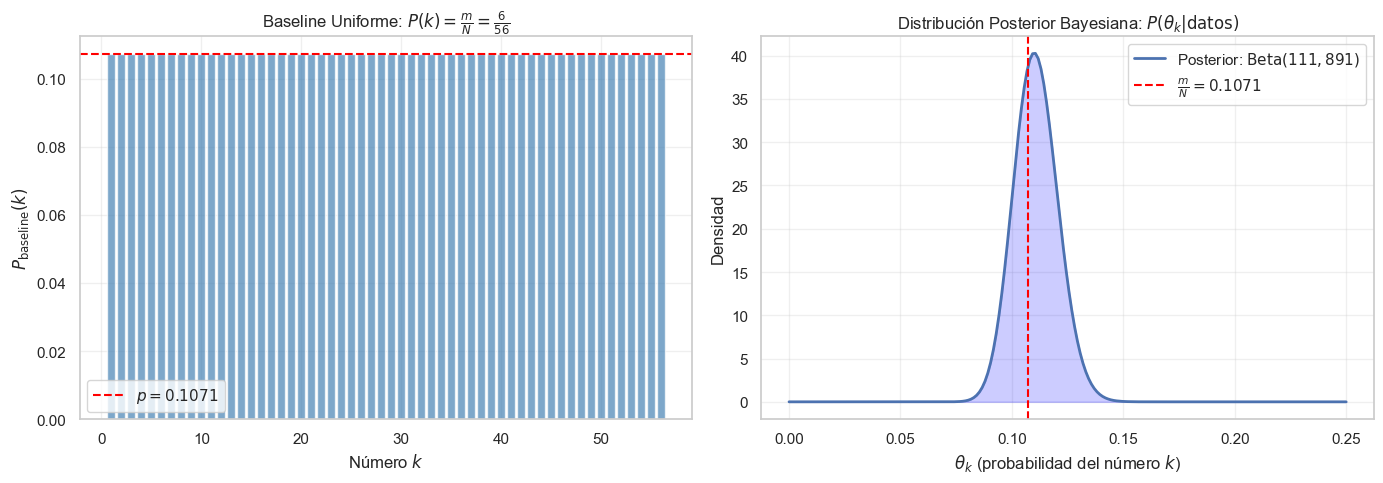


Test de visualizacion con LaTeX: OK


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribucion uniforme (baseline)
N = 56
m = 6
p_baseline = m / N
x = np.arange(1, N + 1)
y_uniform = np.full(N, p_baseline)

axes[0].bar(x, y_uniform, color='steelblue', alpha=0.7)
axes[0].set_title(r'Baseline Uniforme: $P(k) = \frac{m}{N} = \frac{6}{56}$')
axes[0].set_xlabel('Número $k$')
axes[0].set_ylabel(r'$P_{\mathrm{baseline}}(k)$')
axes[0].axhline(y=p_baseline, color='red', linestyle='--', label=f'$p = {p_baseline:.4f}$')
axes[0].legend()

# Grafico 2: Distribucion Beta posterior (ejemplo)
from scipy.stats import beta as beta_dist

x_beta = np.linspace(0, 0.25, 200)
alpha_prior, beta_prior = 1, 1
n_sorteos_ejemplo = 1000
freq_ejemplo = 110  # aparecio 110 de 1000

alpha_post = alpha_prior + freq_ejemplo
beta_post = beta_prior + (n_sorteos_ejemplo - freq_ejemplo)

y_prior = beta_dist.pdf(x_beta, alpha_prior, beta_prior)
y_post = beta_dist.pdf(x_beta, alpha_post, beta_post)

axes[1].plot(x_beta, y_post, 'b-', linewidth=2, label=r'Posterior: $\mathrm{Beta}(111, 891)$')
axes[1].axvline(x=p_baseline, color='red', linestyle='--', label=r'$\frac{m}{N} = 0.1071$')
axes[1].fill_between(x_beta, y_post, alpha=0.2, color='blue')
axes[1].set_title(r'Distribución Posterior Bayesiana: $P(\theta_k | \mathrm{datos})$')
axes[1].set_xlabel(r'$\theta_k$ (probabilidad del número $k$)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/00_test_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTest de visualizacion con LaTeX: OK")

## 0.10 — Configuración de Rutas del Proyecto

In [40]:
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

for d in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(exist_ok=True)

print("Rutas del proyecto:")
print(f"  ROOT:    {PROJECT_ROOT}")
print(f"  DATA:    {DATA_DIR}")
print(f"  MODELS:  {MODELS_DIR}")
print(f"  OUTPUTS: {OUTPUTS_DIR}")

for d in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR]:
    status = 'existe' if d.exists() else 'ERROR'
    print(f"  {d.name}/: {status}")

Rutas del proyecto:
  ROOT:    E:\Documentos\MLT\MLTconIA\MLT
  DATA:    E:\Documentos\MLT\MLTconIA\MLT\data
  MODELS:  E:\Documentos\MLT\MLTconIA\MLT\models
  OUTPUTS: E:\Documentos\MLT\MLTconIA\MLT\outputs
  data/: existe
  models/: existe
  outputs/: existe


## 0.11 — Resumen del Entorno

Generamos un diccionario resumen que se puede reutilizar en notebooks posteriores.

In [41]:
env_summary = {
    'project': PROJECT_NAME,
    'version': PROJECT_VERSION,
    'random_state': RANDOM_STATE,
    'python': sys.version.split()[0],
    'os': f"{platform.system()} {platform.release()}",
    'device': gpu_info['device'],
    'gpu_name': gpu_info['gpu_name'],
    'xgb_gpu': gpu_info['xgb_gpu'],
    'xgb_available': xgb_available,
    'optuna_available': optuna_available,
    'timestamp': datetime.now().isoformat(),
    'libraries': installed,
}

print("=" * 60)
print("  RESUMEN DEL ENTORNO - MLT PREDICCION")
print("=" * 60)
for key, val in env_summary.items():
    if key != 'libraries':
        print(f"  {key:20s}: {val}")

print("\n  Librerias:")
for lib, ver in env_summary['libraries'].items():
    print(f"    {lib:20s}: {ver}")

print("\n" + "=" * 60)
print("  ENTORNO CONFIGURADO CORRECTAMENTE")
print("  Siguiente paso: notebooks/01_data_service.ipynb")
print("=" * 60)

  RESUMEN DEL ENTORNO - MLT PREDICCION
  project             : MLT Prediccion
  version             : 2.0
  random_state        : 42
  python              : 3.12.10
  os                  : Windows 11
  device              : cuda
  gpu_name            : N/A
  xgb_gpu             : True
  xgb_available       : True
  optuna_available    : True
  timestamp           : 2026-03-29T14:46:37.094903

  Librerias:
    numpy               : 2.1.3
    pandas              : 2.3.3
    scipy               : 1.16.2
    scikit-learn        : 1.7.2
    matplotlib          : 3.10.7
    seaborn             : 0.13.2
    requests            : 2.32.4
    joblib              : 1.5.2
    xgboost             : 3.2.0
    optuna              : 4.8.0

  ENTORNO CONFIGURADO CORRECTAMENTE
  Siguiente paso: notebooks/01_data_service.ipynb


---

## Constantes del Juego MLT (Melate)

Estas constantes se usarán en todos los notebooks del proyecto:

| Constante | Valor | Significado |
|-----------|-------|-------------|
| $N$ | 56 | Números posibles en el juego |
| $m$ | 6 | Números seleccionados por sorteo |
| $P_{\text{baseline}}$ | $\frac{6}{56} \approx 0.1071$ | Probabilidad uniforme por número |
| $\mathbb{E}[\text{aciertos}]$ | $\frac{36}{56} \approx 0.643$ | Aciertos esperados por azar |
| $\binom{56}{6}$ | $32,468,436$ | Combinaciones totales posibles |

In [42]:
MLT_N = 56
MLT_M = 6
MLT_P_BASELINE = MLT_M / MLT_N
MLT_E_HITS = MLT_M**2 / MLT_N
MLT_TOTAL_COMBOS = int(comb(MLT_N, MLT_M, exact=True))

print(f"Parametros del juego MLT (Melate):")
print(f"  N (numeros posibles):      {MLT_N}")
print(f"  m (numeros por sorteo):    {MLT_M}")
print(f"  P_baseline por numero:     {MLT_P_BASELINE:.4f} ({MLT_P_BASELINE*100:.2f}%)")
print(f"  E[aciertos] por azar:      {MLT_E_HITS:.3f}")
print(f"  Combinaciones totales:     {MLT_TOTAL_COMBOS:,}")
print(f"  Probabilidad de acertar 6: 1/{MLT_TOTAL_COMBOS:,} = {1/MLT_TOTAL_COMBOS:.2e}")

Parametros del juego MLT (Melate):
  N (numeros posibles):      56
  m (numeros por sorteo):    6
  P_baseline por numero:     0.1071 (10.71%)
  E[aciertos] por azar:      0.643
  Combinaciones totales:     32,468,436
  Probabilidad de acertar 6: 1/32,468,436 = 3.08e-08
